In [1]:
import pickle
import os.path as osp
import os
import numpy as np

results_dir = osp.relpath("./data/results/loo_pretrain_5e-3")

files = os.listdir(results_dir)

angle_errs = []
joint_errs = []
vertex_errs = []
jitter_errs = []

for file in files:
  fpath = osp.join(results_dir, file)

  with open(fpath, 'rb') as f:
    err_dict = pickle.load(f)
    angle_errs.append(err_dict['angle_error'])
    joint_errs.append(err_dict['joint_error'])
    vertex_errs.append(err_dict['vertex_error'])
    jitter_errs.append(err_dict['jitter'])
    
    print('file ' + file)
    print(f'angle error {np.mean(angle_errs[-1])}')
    print(f'joint error {np.mean(joint_errs[-1])}')
    print(f'vertex error {np.mean(vertex_errs[-1])}')
    print(F'jitter {np.mean(jitter_errs[-1])}')
    print()



file helen_error_metrics.pkl
angle error 0.7587432439480488
joint error 13.236551144774625
vertex error 17.508672185382444
jitter 0.0016482283526424865

file jin_error_metrics.pkl
angle error 0.9918728370801311
joint error 14.807443517754956
vertex error 20.274173900459747
jitter 0.0011609857648711265

file evan_error_metrics.pkl
angle error 1.4526467242121943
joint error 18.891789591092607
vertex error 28.394346320764974
jitter 0.0010759834733629634

file vidya_error_metrics.pkl
angle error 0.9301657051976506
joint error 14.147933146856415
vertex error 21.09057127825627
jitter 0.0015032239936597128

file kanav_error_metrics.pkl
angle error 0.7841293374658449
joint error 13.513643984399312
vertex error 19.251220961552967
jitter 0.0011118714755186977

file maggie_error_metrics.pkl
angle error 0.8441421813457367
joint error 13.738942068636044
vertex error 19.458093813668025
jitter 0.0015820576992235415

file michelle_error_metrics.pkl
angle error 0.8170507964178337
joint error 13.5594424

In [2]:
angle_errs = np.array(angle_errs)
joint_errs = np.array(joint_errs)
vertex_errs = np.array(vertex_errs)
jitter = np.array(jitter_errs)

In [3]:
# overall statistics
print(f'average angle error {np.mean(angle_errs)}')
print(f'average joint errors {np.mean(joint_errs)}')
print(f'average vertex errors {np.mean(vertex_errs)}')
print(f'average jitter {np.mean(jitter)}')

average angle error 0.9502270018288076
average joint errors 14.662434486784706
average vertex errors 20.90076490068692
average jitter 0.0015235170056034544


In [22]:
print(f'average joint errors {np.mean(joint_errs, axis=0)}')
print(F'joint err at left ankle {np.mean(joint_errs, axis=0)[7]}')
print(F'joint err at right ankle {np.mean(joint_errs, axis=0)[8]}')

average joint errors [ 0.          4.72868754  5.54600523  2.81460829 15.71505998 14.94659328
  5.05295603 18.28774765 18.58342103  6.7221699  21.43516359 22.62060115
 10.41424904 10.2258246   8.97269479 16.40415622 18.59684311 14.72394773
 23.11941315 24.25794572 33.21379428 31.51868383]
joint err at left ankle 18.28774765430913
joint err at right ankle 18.583421027780304


In [23]:
import smplx
import open3d
from imu_uwb_pose.config import config

config = config()

smpl = smplx.create(config.body_model, model_type='smplx',
                            gender='neutral', use_face_contour=False,
                            batch_size=1,
                            ext='npz',
                            age='adult').to(config.device)

output = smpl()


In [24]:
verts = output.vertices.detach().cpu().numpy()
joints = output.joints.detach().cpu().numpy()
verts = verts[0]
faces = smpl.faces
average_err_verts = np.mean(vertex_errs, axis=0)

In [25]:
def show_colored_mesh(verts, vert_errs, faces, *,
                      cmap_name: str = "Reds",
                      window_name: str | None = None):
    """
    Same API as before, but with shape / value checks that surface
    the exact reason Open3D would have failed.
    """
    import numpy as np
    import open3d as o3d
    import matplotlib.cm as cm

    # --- 0. Convert & sanity-check shapes -------------------------------
    verts = np.asarray(verts,  dtype=np.float64)
    vert_errs = np.asarray(vert_errs, dtype=np.float64).reshape(-1)
    faces = np.asarray(faces, dtype=np.int32)

    assert verts.ndim == 2 and verts.shape[1] == 3, \
        f"`verts` must be (N,3); got {verts.shape}"
    assert faces.ndim == 2 and faces.shape[1] == 3, \
        f"`faces` must be (M,3); got {faces.shape}"
    assert len(verts) == len(vert_errs), \
        f"`vert_errs` ({len(vert_errs)}) != number of vertices ({len(verts)})"

    # No NaNs/Infs
    assert np.isfinite(verts).all(),  "`verts` contains NaN/Inf"
    assert np.isfinite(vert_errs).all(), "`vert_errs` contains NaN/Inf"

    # Face indices in bounds
    assert faces.min() >= 0,                "`faces` has negative indices"
    assert faces.max() < len(verts),        "`faces` index exceeds vertex count"

    # --- 1. Normalise error → [0,1] --------------------------------------
    if np.isclose(np.ptp(vert_errs), 0):
        err_norm = np.zeros_like(vert_errs)
    else:
        err_norm = (vert_errs - vert_errs.min()) / np.ptp(vert_errs)

    # --- 2. Colormap ------------------------------------------------------
    rgb = cm.get_cmap(cmap_name)(err_norm)[:, :3]

    # --- 3. Build mesh ----------------------------------------------------
    mesh = o3d.geometry.TriangleMesh()
    mesh.vertices      = o3d.utility.Vector3dVector(verts)
    mesh.triangles     = o3d.utility.Vector3iVector(faces)
    mesh.vertex_colors = o3d.utility.Vector3dVector(rgb.astype(np.float64))
    mesh.compute_vertex_normals()

    # --- 4. Visualise -----------------------------------------------------
    if window_name is None:
        window_name = "Per-vertex error visualisation"
    o3d.visualization.draw_geometries([mesh],
                                      window_name=window_name,
                                      mesh_show_back_face=True,
                                      width=900, height=700)


In [26]:
import numpy as np
import open3d as o3d
from scipy.stats import norm
from datetime import datetime

def make_smpl_geoms(joints, errors, cfg):
    joints = np.asarray(joints).reshape(22, 3)
    errors = np.asarray(errors).reshape(22,)

    mu = errors.mean()
    std = errors.std()
    if std < 1e-6:
        cdf_vals = np.full_like(errors, 0.5, dtype=np.float64)
    else:
        cdf_vals = norm.cdf(errors, loc=mu, scale=std)
        cdf_vals = np.clip(cdf_vals, 0.0, 1.0)

    colors = np.stack([cdf_vals, np.zeros_like(cdf_vals), 1 - cdf_vals], axis=1)

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(joints)
    pcd.colors = o3d.utility.Vector3dVector(colors)

    skeleton = cfg.get_smpl_skeleton().numpy()
    line_set = o3d.geometry.LineSet()
    line_set.points = o3d.utility.Vector3dVector(joints)
    line_set.lines = o3d.utility.Vector2iVector(skeleton)
    line_set.colors = o3d.utility.Vector3dVector([[0, 0, 0]] * skeleton.shape[0])

    return pcd, line_set

def render_smpl_offscreen(joints, errors, cfg, out_path=None, width=800, height=800):
    if out_path is None:
        out_path = f"skeleton_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"

    pcd, line_set = make_smpl_geoms(joints, errors, cfg)

    try:
        renderer = o3d.visualization.rendering.OffscreenRenderer(width, height)
        # point size lives in the material
        pcd_mat = o3d.visualization.rendering.MaterialRecord()
        pcd_mat.shader = "defaultUnlit"
        pcd_mat.point_size = 12.0   # 👈 bigger dots

        renderer.scene.set_background([1, 1, 1, 1])
        renderer.scene.add_geometry("joints", pcd, pcd_mat)

        line_mat = o3d.visualization.rendering.MaterialRecord()
        line_mat.shader = "unlitLine"
        line_mat.line_width = 2.0
        renderer.scene.add_geometry("skeleton", line_set, line_mat)

        bbox = pcd.get_axis_aligned_bounding_box()
        center = bbox.get_center()
        extent = bbox.get_extent().max()

        eye = center + np.array([0, 0, extent * 1.8])
        up = np.array([0, 1, 0])
        renderer.scene.camera.look_at(center, eye, up)

        img = renderer.render_to_image()
        o3d.io.write_image(out_path, img)
        return out_path

    except Exception as e:
        print("Open3D offscreen failed", e)



[Open3D INFO] EGL headless mode enabled.
FEngine (64 bits) created at 0x1b991100 (threading is enabled)
EGL(1.5)
OpenGL(4.1)


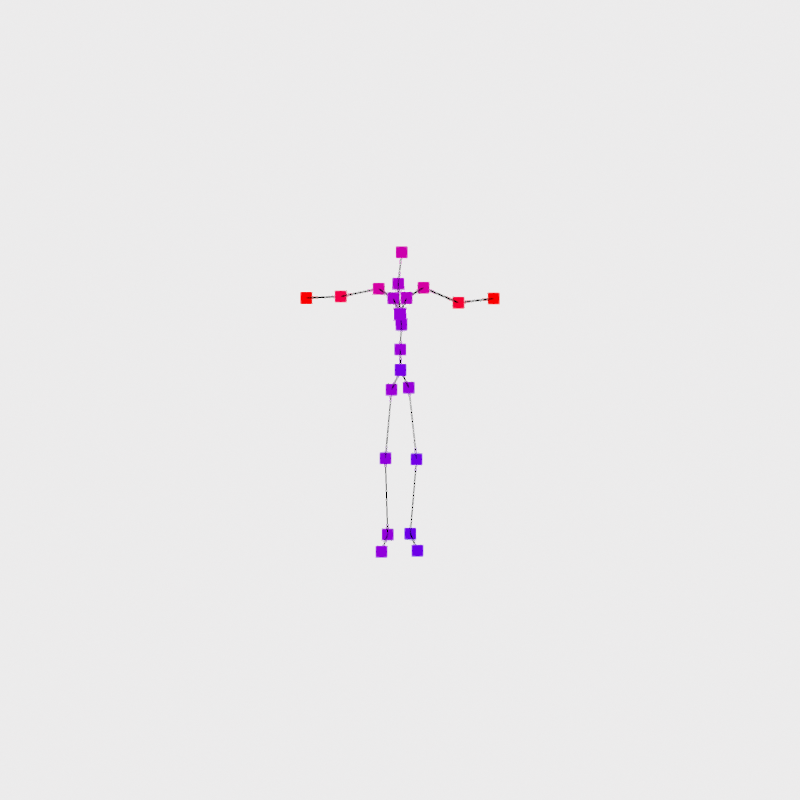

In [27]:
png_path = render_smpl_offscreen(joints[:,:22,:], np.mean(angle_errs,axis=0), config)
from IPython.display import Image, display

display(Image(filename=png_path))